# 批大小对神经网络训练的影响  
在神经网络中，批( batch )是指一次输入网络进行训练或推断的一组样本。批处理( batch processing )是指将这一组样本同时输入网络进行计算的操作。本节中首先介绍批( Batch )的基本概念，并且介绍批大小在神经网络训练过程中的影响。

## 1. 批处理概念  
在深度学习中，批( Batch )是指一次输入神经网络的一组样本，批处理的思想是将多个样本同时输入网络进行计算，通过并行化的方式提高计算效率。   

在[神经网络训练](Notes\6.神经网络性能优化技术.ipynb)中，训练数据集 Fashion MNIST 中每批包含 32 个数据样本，每个 epoch 中权重的更新次数较多，每个 epoch 会更新 1,875 次权重( 60,000/32 ≈ 1,875，其中 60,000 是训练图像的数量)。此外，并没有考虑模型对未见过的数据集(验证数据集)上的性能。  

在本节中，我们将进行以下实验：
- 当训练批大小为 32 时，观察模型在训练和验证数据上的损失和准确度
- 当训练批大小为 30,000 时，观察模型在训练和验证数据上的损失和准确度 
 
如果需要使用验证数据，计算模型在验证数据上的损失和准确度，需要获取验证数据。  

## 2.批处理的优势  
在神经网络训练过程中，批处理具有以下优势：
- 提高计算效率：通过同时处理多个样本，可以充分利用现代计算硬件(如 GPU )的并行计算能力，加快模型的训练和推断速度。相比逐个样本处理，批处理可以在单次计算中同时完成多个样本的前向传播和反向传播操作。
- 稳定梯度计算：批处理能够提供对更多样本的梯度计算，从而减小梯度的随机性，使得训练更加稳定。相比于单个样本的梯度更新，批处理可以平均多个样本的梯度，从而减少了噪声的影响。  
- 有效利用内存：批处理可以将多个样本一次性加载到内存中，减少了数据读取和存储的开销。特别是对于训练集较大的情况下，批处理能够显著降低I/O等方面的负载，提高整体的训练效率。 
   
在训练过程中，通常会将数据集按照随机顺序划分成多个批次，并进行多次迭代训练。这样可以增强模型的泛化能力，并降低对特定顺序的依赖性。

## 3. 批大小对神经网络性能的影响  
在实际模型训练过程中，批大小( batch size )是一个重要的超参数，需要根据具体的任务和资源情况进行选择。较大的批大小可以加速计算，但会增加内存需求；而较小的批大小有利于更好地探索样本空间，但可能导致梯度估计不稳定。

## 3.1 批大小为32  
我们已经在[神经网络](../Notes/6.神经网络性能优化技术.ipynb)训练一节中构建了在训练期间批大小为 32 模型，本节中，我们将重点说明如何处理验证数据集。

1. 下载并导入训练图像和目标值：

In [10]:
from torchvision import datasets
import torch
data_folder = './Start-with-Pytorch/Dataset'
fmnist = datasets.FashionMNIST(data_folder, download = True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

2. 与训练图像类似，需要在调用 FashionMNIST 方法时通过指定 train = False 下载并导入验证数据集：

In [ ]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

3. 导入相关库并定义可用设备：

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = 'cpu'

4. 定义数据集类 FashionMNIST、用于对一批数据进行训练的函数 train_batch()、计算准确率 accuracy()，然后定义模型架构、损失函数和优化器 get_model()：

In [13]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

#单批次训练函数，包含前向传播、损失计算、反向传播和参数更新。
def train_batch(x, y, model, optimizer, batch_loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = batch_loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

#：在不计算梯度的模式下，评估模型在给定批次上的预测准确率。
def accuracy(x, y, model):
    model.eval()
    # 使用 with torch.no_grad() 与 @torch.no_grad 效果相同
    # 在 with 作用域内的并不计算梯度
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

5.  定义用于获取数据的函数 get_data()，此函数将返回批大小为 32 的训练数据和批大小为验证数据长度的验证数据集(验证数据不会用于训练模型，只用于了解模型在的未见过数据上的准确率)：

In [14]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=True)
    return trn_dl, val_dl

在以上代码中，除了 train 对象之外，我们还创建了一个名为 val 的 FMNISTDataset 类的对象。此外，用于验证模型的 DataLoader (val_dl) 批大小为 len (val_images)，而 trn_dl 的批大小为 32。接下来，我们将根据模型的训练时间和准确率来了解不同 batch_size 对模型的影响。

6. 定义计算验证数据损失的函数 val_loss：

In [15]:
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

应用 @torch.no_grad() 声明无需训练模型而只获取预测结果，通过损失函数 loss_fn() 传递预测结果并返回损失值 val_loss.item()。

7. 获取训练和验证数据加载器，并初始化模型、损失函数和优化器：

In [16]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

8. 训练模型
- 首先初始化包含训练准确率、验证准确率和损失值的列表
- 循环 10 个 epoch 并初始化包含给定 epoch 内各批训练数据的准确率和损失的列表
- 遍历一批训练数据并计算一个 epoch 内的准确率( train_epoch_accuracy )和损失值( train_epoch_loss)
- 计算验证数据的损失值和准确率(验证数据的批大小等于验证数据的长度)
- 将训练和验证数据集的准确率和损失值添加相应列表中，以查看模型训练的改进
- 可视化模型训练过程中训练和验证数据集中的准确率和损失值的变化：

0
1
2
3
4
5
6
7
8
9


C:\Users\Admin\AppData\Local\Temp\ipykernel_9552\4067576245.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


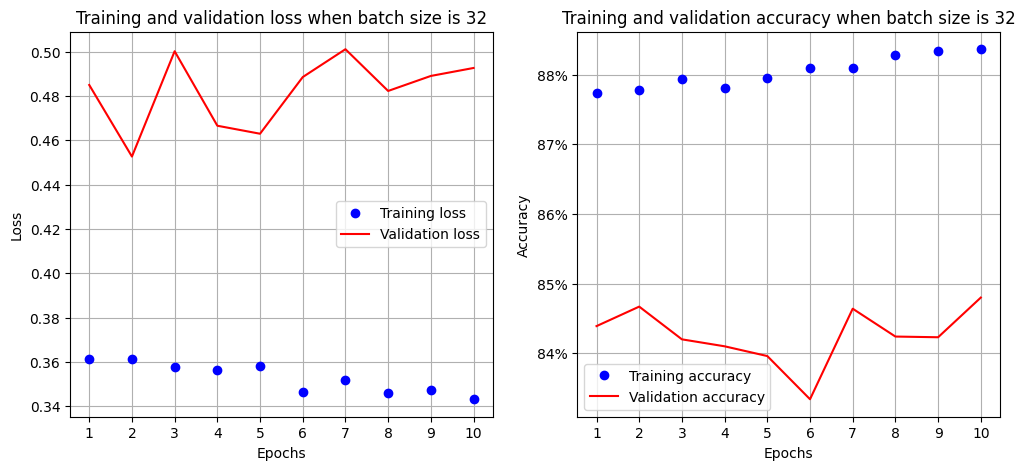

In [18]:
# 初始化记录列表
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# 循环 10 个 epoch
for epoch in range(10):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    
    # 遍历训练集，计算本 epoch 的训练损失和准确率
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        is_correct = accuracy(x, y, model)
        train_epoch_losses.append(batch_loss)
        train_epoch_accuracies.extend(is_correct)
    
    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    
    # 遍历验证集，计算本 epoch 的验证损失和准确率
    val_epoch_losses = []
    val_epoch_accuracies = []
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
        val_epoch_losses.append(validation_loss)
        val_epoch_accuracies.extend(val_is_correct)
    
    val_epoch_loss = np.array(val_epoch_losses).mean()
    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    
    # 记录到全局列表
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

# 可视化训练和验证曲线
epochs = np.arange(10) + 1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.figure(figsize=(12, 5))
# 损失曲线
plt.subplot(121)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')

# 准确率曲线
plt.subplot(122)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')

plt.show()

如上图所示，当批大小为 32 时，在 epoch 结束时，训练和验证数据集上准确率约为 85%。接下来，改变 get_data() 函数中的 DataLoader 的 batch_size 参数，以观察不同批大小对模型准确率的影响。

### 3.2 批大小为30000  
在本节中，将批大小设定为 30,000 (除此之外，代码与上一小节完全相同)，以便了解改变批大小对模型训练的影响。  

修改 get_data() 使其批大小为 30,000，同时从训练数据集中获取训练 DataLoader：

0
1
2
3
4
5
6
7
8
9


C:\Users\Admin\AppData\Local\Temp\ipykernel_9552\3202649791.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


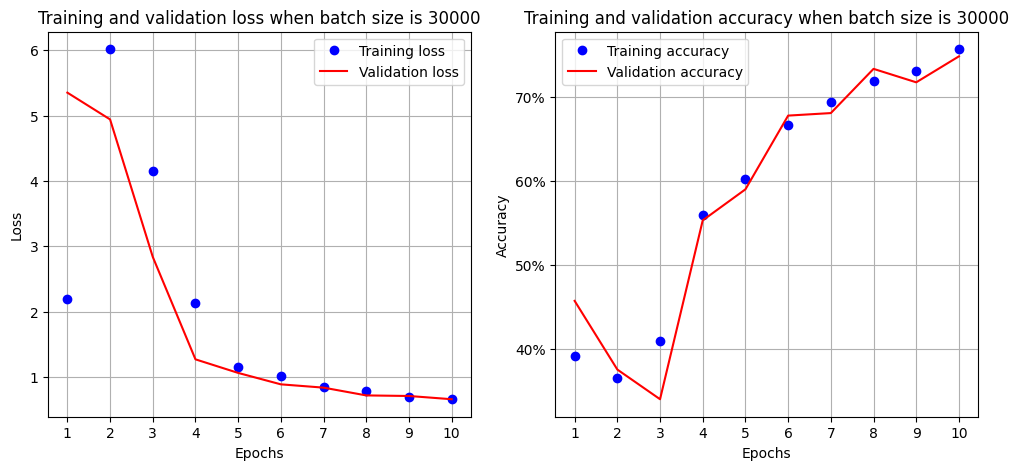

In [19]:
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = 'cpu'

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()/255
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

#单批次训练函数，包含前向传播、损失计算、反向传播和参数更新。
def train_batch(x, y, model, optimizer, batch_loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = batch_loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

#：在不计算梯度的模式下，评估模型在给定批次上的预测准确率。
def accuracy(x, y, model):
    model.eval()
    # 使用 with torch.no_grad() 与 @torch.no_grad 效果相同
    # 在 with 作用域内的并不计算梯度
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=30000, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=True)
    return trn_dl, val_dl

@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

# 初始化记录列表
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# 循环 10 个 epoch
for epoch in range(10):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    
    # 遍历训练集，计算本 epoch 的训练损失和准确率
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        is_correct = accuracy(x, y, model)
        train_epoch_losses.append(batch_loss)
        train_epoch_accuracies.extend(is_correct)
    
    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    
    # 遍历验证集，计算本 epoch 的验证损失和准确率
    val_epoch_losses = []
    val_epoch_accuracies = []
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
        val_epoch_losses.append(validation_loss)
        val_epoch_accuracies.extend(val_is_correct)
    
    val_epoch_loss = np.array(val_epoch_losses).mean()
    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    
    # 记录到全局列表
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)

# 可视化训练和验证曲线
epochs = np.arange(10) + 1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.figure(figsize=(12, 5))
# 损失曲线
plt.subplot(121)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss when batch size is 30000')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')

# 准确率曲线
plt.subplot(122)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy when batch size is 30000')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')

plt.show()

可以看到模型性能(准确率和损失值)不如批大小为 32 的模型，因为当批大小为 32 时，权重的更新次数较多，当批大小为 30,000 时，每个 epoch 仅会进行 2 次( 60000/30000 )权重更新。因此，批大小越小，权重更新的次数就越多，并且通常在 epoch 数相同的情况下，准确率越好。同时，应注意批大小也不能过小，这可能导致训练时间过长，以及过拟合情况的出现。  

与 batch size = 32 的对比  
• 稳定性：batch size = 30000 时曲线更平滑，没有剧烈波动；batch size = 32 时验证集指标震荡明显。  
• 过拟合：batch size = 30000 时几乎没有过拟合；batch size = 32 时过拟合明显。  
• 资源消耗：batch size = 30000 需要更多显存和计算资源，而 batch size = 32 更轻量。  

## 小结  
批处理是神经网络中的重要操作，通过同时处理多个样本来提高计算效率、稳定梯度估计以及有效利用内存。合理选择批大小可以在保证计算效率的同时，获得良好的训练结果。本节中，主要介绍了批大小在神经网络训练过程中的重要作用。